In [7]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
from xgboost import XGBClassifier
import pickle
from statsmodels.stats.contingency_tables import mcnemar

DATA_DIR = 'processed_data'
BASE_DIR = 'Hybrid Model 2.0'
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
BASELINE_DIR = 'models'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class DynamicFusionMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, fusion_dim, dropout_rate):
        super(DynamicFusionMLP, self).__init__()
        self.layers = nn.ModuleList()
        
        self.layers.append(nn.Linear(input_dim, 256))
        self.layers.append(nn.BatchNorm1d(256)) 
        self.layers.append(nn.ReLU())
        self.layers.append(nn.Dropout(dropout_rate))
        
        current_dim = 256
        
        if hidden_layers == 2:
            self.layers.append(nn.Linear(256, 128))
            self.layers.append(nn.BatchNorm1d(128))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(dropout_rate))
            current_dim = 128
            
        self.fusion_layer = nn.Linear(current_dim, fusion_dim)
        self.fusion_act = nn.ReLU()
        
        self.head = nn.Linear(fusion_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        fused_features = self.fusion_act(self.fusion_layer(x))
        return fused_features 

def run_mcnemar_test():
    print(f"\n" + "="*60)
    print(f"McNemar's Statistical Test")
    print("="*60)
    
    print("1. Loading TEST Data...")
    try:
        X_absa_test = np.load(os.path.join(DATA_DIR, 'X_absa_test.npy'))
        X_emo_test  = np.load(os.path.join(DATA_DIR, 'X_emo_test.npy'))
        y_test      = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
        X_concat_test = np.hstack([X_absa_test, X_emo_test])
    except:
        print("❌ Error: Processed data not found.")
        return

    print("2. Generating ABSA-only model Predictions...")
    try:
        with open(os.path.join(BASELINE_DIR, 'ABSA_Baseline_best.pkl'), 'rb') as f:
            absa_model = pickle.load(f)
        y_pred_absa = absa_model.predict(X_absa_test) 
    except Exception as e:
        print(f"❌ Error loading ABSA Baseline: {e}")
        return

    print("3. Generating Hybrid model Predictions...")
    try:
        config_df = pd.read_csv(os.path.join(RESULTS_DIR, 'best_mlp_config.csv'))
        best_config = config_df.iloc[0].to_dict()
        
        mlp = DynamicFusionMLP(
            X_concat_test.shape[1], 
            int(best_config['hidden_layers']), 
            int(best_config['fusion_dim']), 
            best_config['dropout']
        ).to(device)
        
        mlp.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'Best_MLP_Stage1.pth')))
        mlp.eval()
        
        with torch.no_grad():
            feat_gpu = mlp(torch.FloatTensor(X_concat_test).to(device))
            X_fused_test = feat_gpu.cpu().numpy()
            
        # np.save(os.path.join(DATA_DIR, 'X_fused_TEST_hybrid_2.0.npy'), X_fused_test)
            
        with open(os.path.join(MODEL_DIR, 'Final_Hybrid_XGBoost.pkl'), 'rb') as f:
            hybrid_xgb = pickle.load(f)
            
        y_pred_hybrid = hybrid_xgb.predict(X_fused_test)
        
    except Exception as e:
        print(f"❌ Error loading Hybrid Model: {e}")
        return

    print("\n4. Calculating ...")
    
    correct_absa = (y_pred_absa == y_test)
    correct_hybrid = (y_pred_hybrid == y_test)

    n_both_correct = np.sum(correct_absa & correct_hybrid)
    n_both_wrong = np.sum(~correct_absa & ~correct_hybrid)
    n_hybrid_win = np.sum(~correct_absa & correct_hybrid) 
    n_hybrid_loss = np.sum(correct_absa & ~correct_hybrid)
    
    table = [[n_both_correct, n_hybrid_loss],
             [n_hybrid_win,   n_both_wrong]]
    
    print(f"   Both Correct: {n_both_correct}")
    print(f"   Both Wrong:   {n_both_wrong}")
    print(f"   Hybrid Right, ABSA Wrong: {n_hybrid_win}")
    print(f"   Hybrid Wrong, ABSA Right: {n_hybrid_loss}")
    

    result = mcnemar(table, exact=False, correction=True)
    
    print("\n" + "="*60)
    print("STATISTICAL RESULT")
    print("="*60)
    print(f"   p-value: {result.pvalue:.5f}")
    
    alpha = 0.05
    if result.pvalue < alpha:
        print(f"   ✅ SIGNIFICANT (p < 0.05)")
        print("   Conclusion: The Hybrid Model is statistically superior to the ABSA Baseline.")
    else:
        print(f"   NOT SIGNIFICANT (p >= 0.05)")
        print("   Conclusion: The difference might be due to chance.")

if __name__ == "__main__":
    run_mcnemar_test()


McNemar's Statistical Test
1. Loading TEST Data...
2. Generating ABSA-only model Predictions...
3. Generating Hybrid model Predictions...

4. Calculating ...
   Both Correct: 187
   Both Wrong:   19
   Hybrid Right, ABSA Wrong: 20
   Hybrid Wrong, ABSA Right: 14

STATISTICAL RESULT
   p-value: 0.39117
   NOT SIGNIFICANT (p >= 0.05)
   Conclusion: The difference might be due to chance.


In [10]:

DATA_DIR = 'processed_data'
BASE_DIR = 'Hybrid Model 2.0'
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
BASELINE_DIR = 'models'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class DynamicFusionMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, fusion_dim, dropout_rate):
        super(DynamicFusionMLP, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, 256))
        self.layers.append(nn.BatchNorm1d(256))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.Dropout(dropout_rate))
        
        current_dim = 256
        if hidden_layers == 2:
            self.layers.append(nn.Linear(256, 128))
            self.layers.append(nn.BatchNorm1d(128))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(dropout_rate))
            current_dim = 128
            
        self.fusion_layer = nn.Linear(current_dim, fusion_dim)
        self.fusion_act = nn.ReLU()
        self.head = nn.Linear(fusion_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        fused_features = self.fusion_act(self.fusion_layer(x))
        return fused_features 

def run_emotion_vs_hybrid():
    print(f"\n" + "="*60)
    print(f"McNemar's Test: Hybrid vs. Emotion-only model")
    print("="*60)
    
    try:
        X_emo_test  = np.load(os.path.join(DATA_DIR, 'X_emo_test.npy'))
        X_absa_test = np.load(os.path.join(DATA_DIR, 'X_absa_test.npy'))
        y_test      = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
        X_concat_test = np.hstack([X_absa_test, X_emo_test])
    except:
        print("❌ Data not found.")
        return

    print("2. Generating Emotion Baseline Predictions...")
    try:
        with open(os.path.join(BASELINE_DIR, 'Emotion_Baseline_best.pkl'), 'rb') as f:
            emo_model = pickle.load(f)
        y_pred_emo = emo_model.predict(X_emo_test) # Note: Uses only Emotion features
    except Exception as e:
        print(f"❌ Error loading Emotion Baseline: {e}")
        return

    print("3. Generating Hybrid Predictions...")
    try:
        config_df = pd.read_csv(os.path.join(RESULTS_DIR, 'best_mlp_config.csv'))
        best_config = config_df.iloc[0].to_dict()
        
        mlp = DynamicFusionMLP(
            X_concat_test.shape[1], 
            int(best_config['hidden_layers']), 
            int(best_config['fusion_dim']), 
            best_config['dropout']
        ).to(device)
        mlp.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'Best_MLP_Stage1.pth')))
        mlp.eval()
        
        with torch.no_grad():
            feat = mlp(torch.FloatTensor(X_concat_test).to(device))
            X_fused = feat.cpu().numpy()
            
        with open(os.path.join(MODEL_DIR, 'Final_Hybrid_XGBoost.pkl'), 'rb') as f:
            hybrid_xgb = pickle.load(f)
        y_pred_hybrid = hybrid_xgb.predict(X_fused)
        
    except Exception as e:
        print(f"❌ Error loading Hybrid: {e}")
        return

    correct_emo = (y_pred_emo == y_test)
    correct_hybrid = (y_pred_hybrid == y_test)
    
    n_both_correct = np.sum(correct_emo & correct_hybrid)
    n_both_wrong = np.sum(~correct_emo & ~correct_hybrid)
    n_hybrid_win = np.sum(~correct_emo & correct_hybrid)   # Hybrid Right, Emo Wrong
    n_hybrid_loss = np.sum(correct_emo & ~correct_hybrid)  # Hybrid Wrong, Emo Right
    
    table = [[n_both_correct, n_hybrid_loss],
             [n_hybrid_win,   n_both_wrong]]
    
    print(f"   Both Correct: {n_both_correct}")
    print(f"   Both Wrong:   {n_both_wrong}")
    print(f"   Hybrid Right, Emotion Wrong: {n_hybrid_win}")
    print(f"   Hybrid Wrong, Emotion Right: {n_hybrid_loss}")
    
    result = mcnemar(table, exact=False, correction=True)
    
    print("\n" + "="*60)
    print(f"   p-value: {result.pvalue:.10f}")
    if result.pvalue < 0.05:
        print("   ✅ SIGNIFICANT (The Hybrid Model is statistically superior to the Emotion Baseline)")
    else:
        print("   NOT SIGNIFICANT")

if __name__ == "__main__":
    run_emotion_vs_hybrid()


McNemar's Test: Hybrid vs. Emotion-only model
2. Generating Emotion Baseline Predictions...
3. Generating Hybrid Predictions...
   Both Correct: 174
   Both Wrong:   26
   Hybrid Right, Emotion Wrong: 33
   Hybrid Wrong, Emotion Right: 7

   p-value: 0.0000772268
   ✅ SIGNIFICANT (The Hybrid Model is statistically superior to the Emotion Baseline)


# AUC-ROC

Loading results...


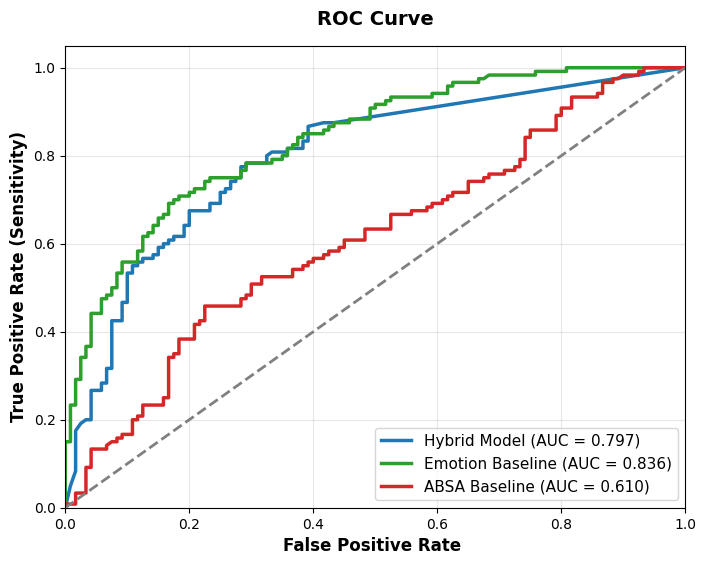

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


print("Loading results...")
df = pd.read_csv('./test_results/main_results.csv')


y_true = df['deceptive_flag'].astype(int)

def get_fraud_prob(row, verdict_col, conf_col):
    if str(row[verdict_col]).strip().upper() == 'FRAUD':
        return row[conf_col]
    else:
        return 1.0 - row[conf_col]


models = {
    'Hybrid Model': ('Hybrid_Verdict', 'Hybrid_Confidence', '#1f77b4'),    
    'Emotion Baseline': ('Emotion_Verdict', 'Emotion_Confidence', '#2ca02c'), 
    'ABSA Baseline': ('ABSA_Verdict', 'ABSA_Confidence', '#d62728')          
}


plt.figure(figsize=(8, 6))


for model_name, (verdict_col, conf_col, color) in models.items():

    y_scores = df.apply(lambda row: get_fraud_prob(row, verdict_col, conf_col), axis=1)
    

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    

    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{model_name} (AUC = {roc_auc:.3f})')


plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate ', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('ROC Curve', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)


plt.show()